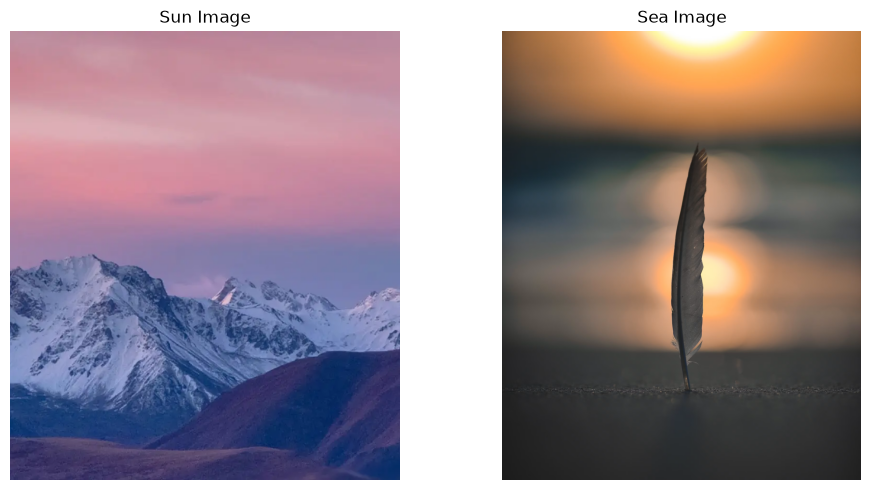

In [3]:
import cv2
import matplotlib.pyplot as plt

sun_bgr = cv2.imread('images/sun.png')
sea_bgr = cv2.imread('images/sea.png')

sun_rgb = cv2.cvtColor(sun_bgr, cv2.COLOR_BGR2RGB)
sea_rgb = cv2.cvtColor(sea_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(sun_rgb)
plt.title('Sun Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sea_rgb)
plt.title('Sea Image')
plt.axis('off')

plt.tight_layout()
plt.show()

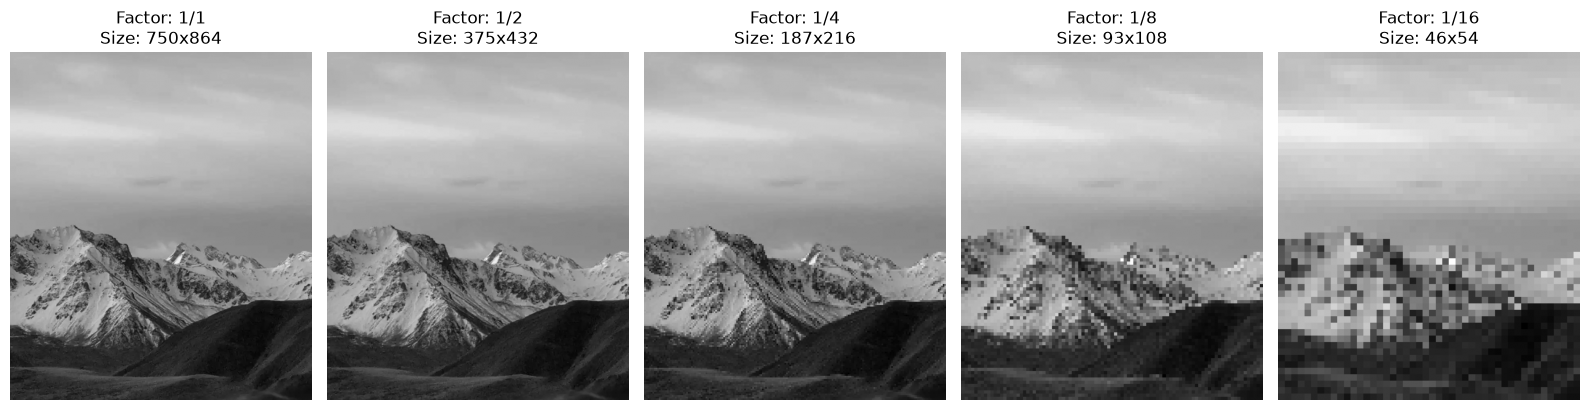

In [4]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('images/sun.png', cv2.IMREAD_GRAYSCALE)

factors = [1, 2, 4, 8, 16]

plt.figure(figsize=(16, 4))

for i, factor in enumerate(factors):
    h, w = img.shape[:2]
    new_h, new_w = int(h / factor), int(w / factor)
    
    downsampled = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    
    resampled = cv2.resize(downsampled, (w, h), interpolation=cv2.INTER_NEAREST)
    
    plt.subplot(1, len(factors), i + 1)
    plt.imshow(resampled, cmap='gray')
    plt.title(f'Factor: 1/{factor}\nSize: {new_w}x{new_h}')
    plt.axis('off')

plt.tight_layout()
plt.show()

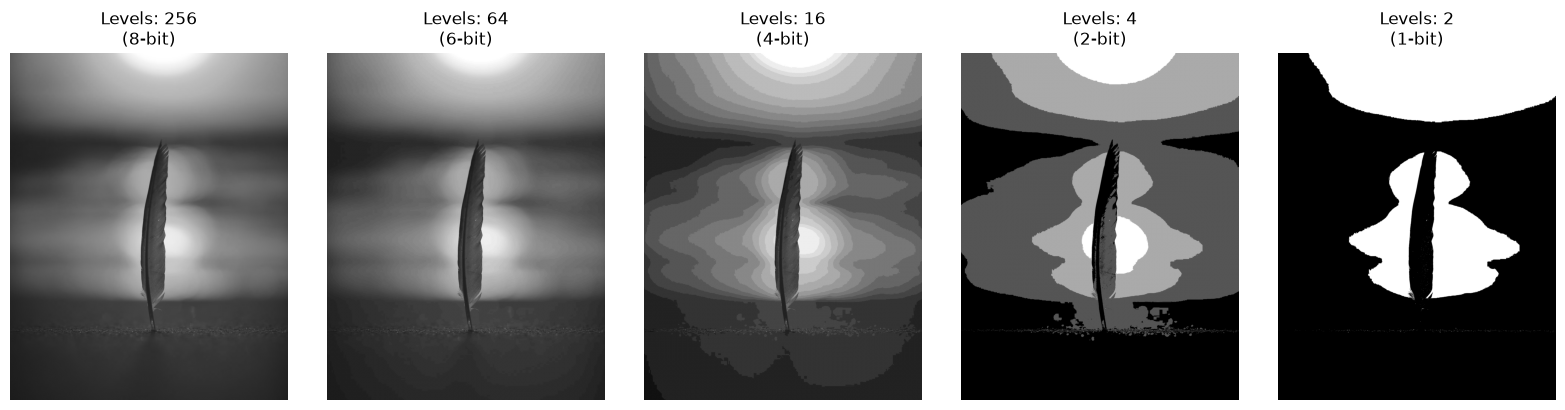

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('images/sea.png', cv2.IMREAD_GRAYSCALE)

levels_list = [256, 64, 16, 4, 2]

plt.figure(figsize=(16, 4))

for i, levels in enumerate(levels_list):
    interval = 256 // levels
    quantized_img = (img // interval) * interval
    
    bits = int(np.log2(levels))
    
    plt.subplot(1, len(levels_list), i + 1)
    plt.imshow(quantized_img, cmap='gray')
    plt.title(f'Levels: {levels}\n({bits}-bit)')
    plt.axis('off')

plt.tight_layout()
plt.show()

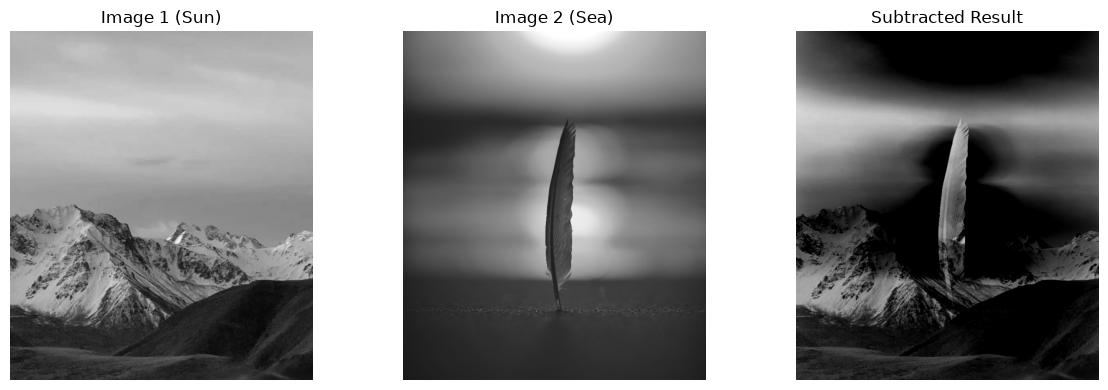

In [6]:
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread('images/sun.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('images/sea.png', cv2.IMREAD_GRAYSCALE)

img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

subtracted = cv2.subtract(img1, img2)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(img1, cmap='gray'); plt.title('Image 1 (Sun)'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(img2, cmap='gray'); plt.title('Image 2 (Sea)'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(subtracted, cmap='gray'); plt.title('Subtracted Result'); plt.axis('off')
plt.tight_layout()
plt.show()

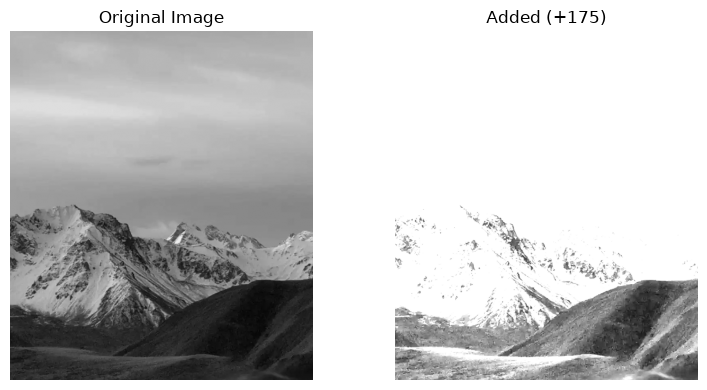

In [7]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('images/sun.png', cv2.IMREAD_GRAYSCALE)

added_img = cv2.add(img, 175)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(added_img, cmap='gray'); plt.title('Added (+175)'); plt.axis('off')
plt.tight_layout()
plt.show()

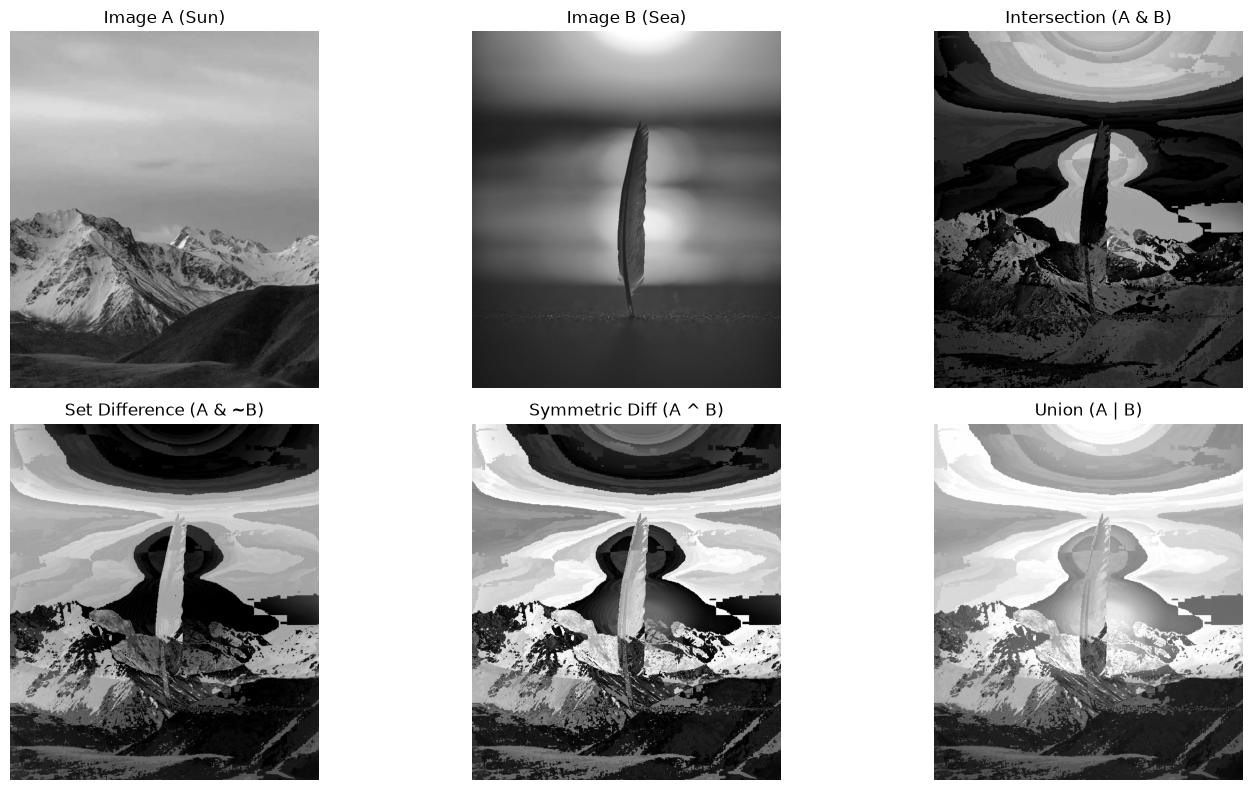

In [8]:
import cv2
import matplotlib.pyplot as plt

A = cv2.imread('images/sun.png', cv2.IMREAD_GRAYSCALE)
B = cv2.imread('images/sea.png', cv2.IMREAD_GRAYSCALE)
B = cv2.resize(B, (A.shape[1], A.shape[0]))

intersection = cv2.bitwise_and(A, B)                          
set_diff = cv2.bitwise_and(A, cv2.bitwise_not(B))             
sym_diff = cv2.bitwise_xor(A, B)                              
union_extra = cv2.bitwise_or(A, B)                           

titles = ['Image A (Sun)', 'Image B (Sea)', 'Intersection (A & B)', 
          'Set Difference (A & ~B)', 'Symmetric Diff (A ^ B)', 'Union (A | B)']
images = [A, B, intersection, set_diff, sym_diff, union_extra]

plt.figure(figsize=(15, 8))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()